In [ ]:
import pandas as pd

# 1. Đọc tệp dữ liệu
file_name = 'FDP_VN_2010_2022_Train_Set.csv'
df = pd.read_csv(file_name)

# 2. Xác định cột mục tiêu
target_col = 'Next_year_binary_distress_label'

# 3. Tính toán số lượng và tỷ lệ phần trăm
counts = df[target_col].value_counts()
percentages = df[target_col].value_counts(normalize=True) * 100

# 4. Hiển thị kết quả dưới dạng bảng
distribution = pd.DataFrame({
    'Số lượng (Count)': counts,
    'Tỷ lệ (%)': percentages
})

print("--- Phân bổ các lớp trong dữ liệu ---")
print(distribution)

# 5. Giải thích kết quả
# Nhãn 0: Doanh nghiệp An toàn (Soundness)
# Nhãn 1: Doanh nghiệp Kiệt quệ (Distress)

--- Phân bổ các lớp trong dữ liệu ---
                                 Số lượng (Count)  Tỷ lệ (%)
Next_year_binary_distress_label                             
0                                            9527  75.145922
1                                            3151  24.854078


In [ ]:
import pandas as pd
import torch
from transformers import pipeline
from tqdm import tqdm
from sqlalchemy import create_engine

DB_CONFIG = {
    'host': '127.0.0.1',
    'user': 'root',
    'password': 'password',
    'database': 'cafef_news_db',
    'charset': 'utf8mb4'
}
SOURCE_TABLE = 'company_news_v2'

# 2. Kết nối
connection_str = f"mysql+pymysql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}/{DB_CONFIG['database']}?charset={DB_CONFIG['charset']}"
engine = create_engine(connection_str)

# 3. Thiết bị chạy 
device = "mps" if torch.backends.mps.is_available() else -1
print(f"Đang dùng thiết bị: {device}")

# 4. Load Model 
print("Đang tải model PhoBERT... đợi xíu nhé...")
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="wonrax/phobert-base-vietnamese-sentiment",
    tokenizer="wonrax/phobert-base-vietnamese-sentiment",
    device=device
)

Đang dùng thiết bị: mps
Đang tải model PhoBERT... đợi xíu nhé...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1974.89it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: wonrax/phobert-base-vietnamese-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Từ điển Lexicon (Baseline)
lexicon_pos = ['lãi', 'tăng trưởng', 'vượt', 'tích cực', 'hợp tác', 'cải thiện', 'phục hồi', 'tăng']
lexicon_neg = ['lỗ', 'giảm', 'cảnh báo', 'kiểm soát', 'đình chỉ', 'vi phạm', 'sụt giảm', 'thua lỗ', 'kém']

def predict_lexicon(text):
    text = str(text).lower()
    pos_score = sum(1 for word in lexicon_pos if word in text)
    neg_score = sum(1 for word in lexicon_neg if word in text)
    return 1 if pos_score > neg_score else (-1 if neg_score > pos_score else 0)

def get_phobert_sentiment(text, threshold):
    res = sentiment_analyzer(text, truncation=True, max_length=256)[0]
    score, label = res["score"], res["label"]
    if score < threshold: return 0
    return 1 if label in ["POS", "POSITIVE"] else (-1 if label in ["NEG", "NEGATIVE"] else 0)

In [ ]:
from sqlalchemy import text

# 1. Lấy mẫu nhạy cảm, loại bỏ dấu ":" và các tin vi phạm công bố thông tin
# Mình dùng "vi phạm công bố thông tin" làm từ khóa lọc để loại bỏ các biến thể tương tự
query = f"""
    SELECT title, content
    FROM {SOURCE_TABLE}
    WHERE (title LIKE '%%lỗ%%' OR title LIKE '%%lãi%%')
      AND title NOT LIKE '%%:%%'
      AND title NOT LIKE '%%,%%'
      AND title NOT LIKE '%%vi phạm công bố thông tin%%'
      AND title NOT LIKE '%%Hàng loạt%%'
    LIMIT 50
"""

# Dùng engine.connect() để thực thi
with engine.connect() as conn:
    df_test = pd.read_sql(text(query), conn)

# 2. Chạy dự báo
tqdm.pandas()
print(f"Đã load {len(df_test)} bài báo sạch. Đang phân tích...")

# Sử dụng hàm dự báo đã có
df_test['Lexicon'] = df_test['title'].apply(predict_lexicon)
df_test['PhoBERT_0.7'] = df_test['title'].progress_apply(lambda x: get_phobert_sentiment(x, 0.7))

# 3. Hiển thị bảng so sánh
pd.set_option('display.max_colwidth', 150)
mapping = {1: "Tích cực", -1: "Tiêu cực", 0: "Trung lập"}

df_display = df_test.copy()
df_display['Lexicon'] = df_display['Lexicon'].map(mapping)
df_display['PhoBERT_0.7'] = df_display['PhoBERT_0.7'].map(mapping)

print("\n" + "!"*30)
print("BẢNG ĐỐI CHIẾU KẾT QUẢ (ĐÃ LỌC TIN RÁC)")
print("!"*30)

# Lọc ra những dòng mà PhoBERT 0.7 khác với Lexicon để làm bằng chứng
diff_samples = df_display[df_test['Lexicon'] != df_test['PhoBERT_0.7']]

if not diff_samples.empty:
    display(diff_samples[['title', 'Lexicon', 'PhoBERT_0.7']].head(20))
else:
    print("Mẫu hiện tại chưa thấy sự khác biệt. Linh có thể bỏ bớt điều kiện hoặc tăng LIMIT nhé!")

Đã load 50 bài báo sạch. Đang phân tích...


100%|██████████| 50/50 [00:02<00:00, 23.16it/s]


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
BẢNG ĐỐI CHIẾU KẾT QUẢ (ĐÃ LỌC TIN RÁC)
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


,title,Lexicon,PhoBERT_0.7
0,PTL cơ bản hoàn thành kế hoạch lợi nhuận quý III/2010,Trung lập,Tích cực
22,ITA xin trả lại dự án chậm tiến độ,Trung lập,Tiêu cực
23,"Báo Tiền Phong trả lời khiếu nại về bài báo ""Về hai siêu dự án của Tập đoàn Tân Tạo tại Kiên Giang""",Trung lập,Tiêu cực
24,AAA ước đạt 30 tỷ đồng lợi nhuận 6 tháng đầu năm 2010,Trung lập,Tích cực
26,Giải mã cổ phiếu lỗ liên tục tăng giá,Trung lập,Tiêu cực
28,GLT đạt lợi nhuận sau thuế 40 tỷ đồng,Trung lập,Tích cực
32,THT ước đạt 32 tỷ đồng lợi nhuận 9 tháng đầu năm 2010,Trung lập,Tích cực
35,TBC dự kiến lợi nhuận thấp hơn năm 2009,Trung lập,Tiêu cực
36,Giải mã cổ phiếu lỗ liên tục tăng giá,Trung lập,Tiêu cực
37,Toà lại bác đơn kiện của IFS,Trung lập,Tiêu cực


In [ ]:
import pandas as pd

data = [
    {"title": "KKC đặt kế hoạch lãi trước thuế 15 tỷ đồng", "Lexicon": "Tích cực", "PhoBERT_0.7": "Trung lập"},
    {"title": "ITA xin trả lại dự án chậm tiến độ", "Lexicon": "Trung lập", "PhoBERT_0.7": "Tiêu cực"},
    {"title": "HSG - Lợi thế thành thất thế?", "Lexicon": "Trung lập", "PhoBERT_0.7": "Tiêu cực"},
    {"title": "MPC đạt chuẩn Global Gap", "Lexicon": "Trung lập", "PhoBERT_0.7": "Tích cực"},
    {"title": "PTL cơ bản hoàn thành kế hoạch lợi nhuận quý III/2010", "Lexicon": "Trung lập", "PhoBERT_0.7": "Tích cực"},
    {"title": "Giải mã cổ phiếu lỗ liên tục tăng giá", "Lexicon": "Trung lập", "PhoBERT_0.7": "Tiêu cực"}
]

# Tạo DataFrame
df_final = pd.DataFrame(data)

# Cấu hình hiển thị
pd.set_option('display.max_colwidth', 100)

print("BẢNG ĐỐI CHIẾU MẪU TIÊU BIỂU CHO BÁO CÁO")
display(df_final[[ 'title', 'Lexicon', 'PhoBERT_0.7']])

BẢNG ĐỐI CHIẾU MẪU TIÊU BIỂU CHO BÁO CÁO


,title,Lexicon,PhoBERT_0.7
0,KKC đặt kế hoạch lãi trước thuế 15 tỷ đồng,Tích cực,Trung lập
1,ITA xin trả lại dự án chậm tiến độ,Trung lập,Tiêu cực
2,HSG - Lợi thế thành thất thế?,Trung lập,Tiêu cực
3,MPC đạt chuẩn Global Gap,Trung lập,Tích cực
4,PTL cơ bản hoàn thành kế hoạch lợi nhuận quý III/2010,Trung lập,Tích cực
5,Giải mã cổ phiếu lỗ liên tục tăng giá,Trung lập,Tiêu cực


In [ ]:
# 1. Phân loại Tin xấu (Low SEN) và Tin tốt (High SEN) dựa trên trung vị
sen_median = df['SEN'].median()
df['SEN_Type'] = df['SEN'].apply(lambda x: 'Tin_Xau' if x < sen_median else 'Tin_Tot')

# 2. Chia nhóm quy mô (Size) như cũ
size_median = df['X15'].median()
df['Size_Group'] = df['X15'].apply(lambda x: 'Nho' if x <= size_median else 'Lon')

# 3. Tính tỷ lệ Kiệt quệ (Target=1) trong từng trường hợp
analysis = df.groupby(['Size_Group', 'SEN_Type'])['Next_year_binary_distress_label'].mean() * 100

print("--- TỶ LỆ DOANH NGHIỆP BỊ KIỆT QUÊ (%) ---")
print(analysis)

# 4. Tính "Mức độ tác động" (Sự chênh lệch rủi ro giữa tin xấu và tin tốt)
impact_small = analysis['Nho']['Tin_Xau'] - analysis['Nho']['Tin_Tot']
impact_large = analysis['Lon']['Tin_Xau'] - analysis['Lon']['Tin_Tot']

print(f"\nSự gia tăng rủi ro khi có tin xấu ở cty NHỎ: {impact_small:.2f}%")
print(f"Sự gia tăng rủi ro khi có tin xấu ở cty LỚN: {impact_large:.2f}%")

--- TỶ LỆ DOANH NGHIỆP BỊ KIỆT QUÊ (%) ---
Size_Group  SEN_Type
Lon         Tin_Tot     19.175481
            Tin_Xau     25.000000
Nho         Tin_Tot     29.953302
            Tin_Xau     26.427504
Name: Next_year_binary_distress_label, dtype: float64

Sự gia tăng rủi ro khi có tin xấu ở cty NHỎ: -3.53%
Sự gia tăng rủi ro khi có tin xấu ở cty LỚN: 5.82%


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


--- Mô hình đã được huấn luyện thành công ---


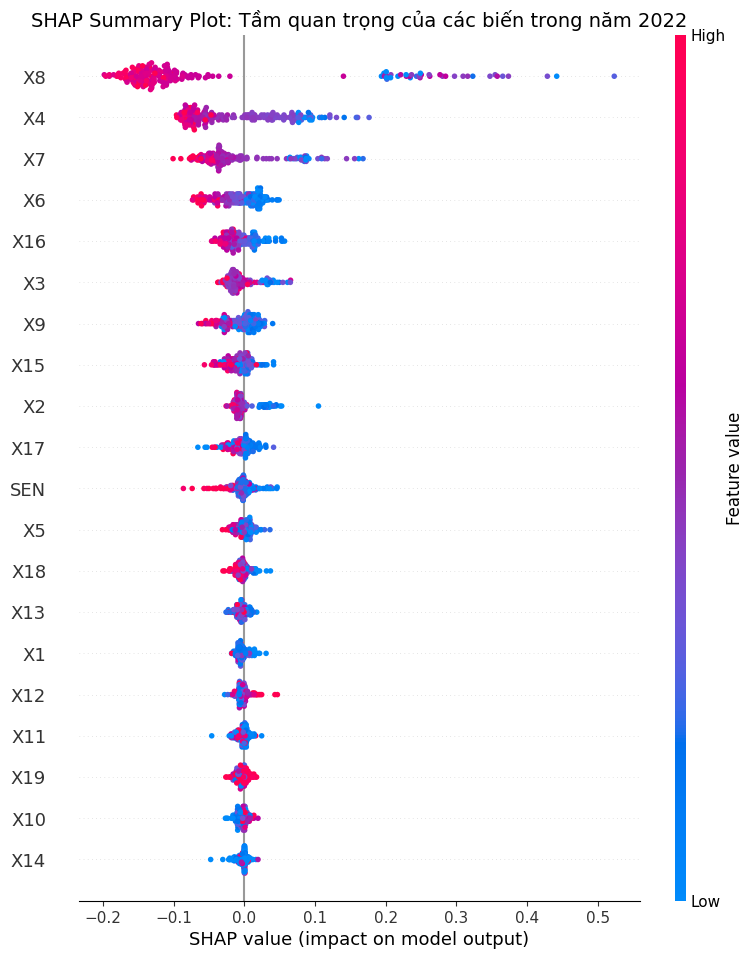


Không tìm thấy mẫu tin xấu làm tăng rủi ro trong các mẫu được chọn.


In [ ]:
import pandas as pd
import numpy as np
import wandb
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# ==========================================
# 1. CẤU HÌNH VÀ ĐĂNG NHẬP WANDB
# ==========================================
WANDB_API_KEY = "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"
wandb.login(key=WANDB_API_KEY)
api = wandb.Api()

# ==========================================
# 2. LOAD DỮ LIỆU
# ==========================================
file_path = "/content/drive/MyDrive/KLTN/FDP_VN_2010_2022_Train_Set.csv"
df_raw = pd.read_csv(file_path)

# Chia tập dữ liệu: Huấn luyện đến 2021, Kiểm thử năm 2022 (Năm khủng hoảng)
train_df = df_raw[df_raw['Year'] <= 2021].copy()
test_df  = df_raw[df_raw['Year'] == 2022].copy()

target = 'Next_year_binary_distress_label'
fin_vars = [f'X{i}' for i in range(1, 20)]
features_fin_sen = fin_vars + ['SEN']

# ==========================================
# 3. LẤY THAM SỐ TỐI ƯU VÀ HUẤN LUYỆN
# ==========================================
# Lấy config từ Run thành công nhất trên WandB
run = api.run("22028316-uet-vnu/Distress_Prediction_KLTN/runs/nhxxygx7")
best_params = {k.replace('rf__', ''): v for k, v in run.config.items()
               if 'rf__' in k or k in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features', 'bootstrap']}

# Xây dựng Pipeline (Scaler -> SMOTE -> RF)
final_pipe = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(**best_params, random_state=42))
])

# Huấn luyện mô hình
final_pipe.fit(train_df[features_fin_sen], train_df[target])
print("--- Mô hình đã được huấn luyện thành công ---")

# ==========================================
# 4. PHÂN TÍCH SHAP TRÊN DỮ LIỆU 2022
# ==========================================
X_test_sen = test_df[features_fin_sen]
X_test_scaled = final_pipe.named_steps['scaler'].transform(X_test_sen)
rf_model = final_pipe.named_steps['rf']

# Khởi tạo Explainer
explainer = shap.TreeExplainer(rf_model)
num_samples = min(200, len(X_test_scaled)) # Lấy 200 mẫu để phân tích
shap_values = explainer.shap_values(X_test_scaled[:num_samples])

# Lấy SHAP values cho class 1 (Kiệt quệ tài chính)
if isinstance(shap_values, list):
    shap_values_distress = shap_values[1]
    expected_value = explainer.expected_value[1]
else:
    shap_values_distress = shap_values[:, :, 1]
    expected_value = explainer.expected_value[1]

# Vẽ Summary Plot tổng quát
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_distress, X_test_scaled[:num_samples],
                  feature_names=features_fin_sen, show=False)
plt.title("SHAP Summary Plot: Tầm quan trọng của các biến trong năm 2022", fontsize=14)
plt.show()

# ==========================================
# 5. TÌM DOANH NGHIỆP MẪU TIÊU BIỂU (CASE STUDY)
# ==========================================
# Mục tiêu: Tìm doanh nghiệp có tin xấu (SEN < 0) và tin xấu đó làm tăng rủi ro (SHAP > 0)
sen_idx = features_fin_sen.index('SEN')
mask = (test_df['SEN'].values[:num_samples] < 0) & (shap_values_distress[:, sen_idx] > 0)
candidate_indices = np.where(mask)[0]

if len(candidate_indices) > 0:
    # Chọn doanh nghiệp mà SEN có tác động đẩy rủi ro mạnh nhất (SHAP cao nhất)
    best_sample_idx = candidate_indices[np.argmax(shap_values_distress[candidate_indices, sen_idx])]

    selected_code = test_df.iloc[best_sample_idx]['Code']
    selected_sen_val = test_df.iloc[best_sample_idx]['SEN']

    print(f"\n--- ĐÃ TÌM THẤY DOANH NGHIỆP MẪU LÝ TƯỞNG: {selected_code} ---")
    print(f"Giá trị SEN thực tế: {selected_sen_val:.4f}")
    print(f"Đóng góp của SEN vào rủi ro (SHAP value): {shap_values_distress[best_sample_idx, sen_idx]:.4f}")

    # Vẽ Waterfall plot cho mẫu này
    plt.figure(figsize=(12, 8))
    shap.plots._waterfall.waterfall_legacy(
        expected_value,
        shap_values_distress[best_sample_idx],
        feature_names=features_fin_sen,
        max_display=15
    )
    plt.title(f"Giải thích rủi ro cho {selected_code} (Bối cảnh thị trường 2022)", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("\nKhông tìm thấy mẫu tin xấu làm tăng rủi ro trong các mẫu được chọn.")

Vẫn không tìm thấy tin xấu làm tăng rủi ro. Đang tìm mẫu SEN có tác động mạnh nhất nói chung...

--- ĐÃ TÌM THẤY DOANH NGHIỆP MẪU: SIP ---
Giá trị SEN thực tế: 0.6752
SHAP value của SEN: -0.0861


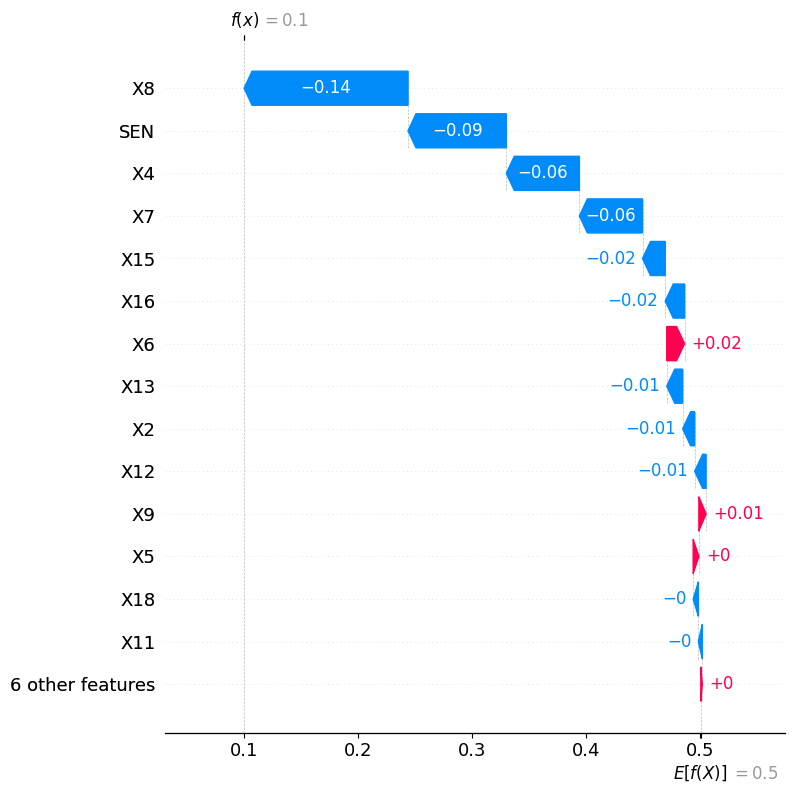

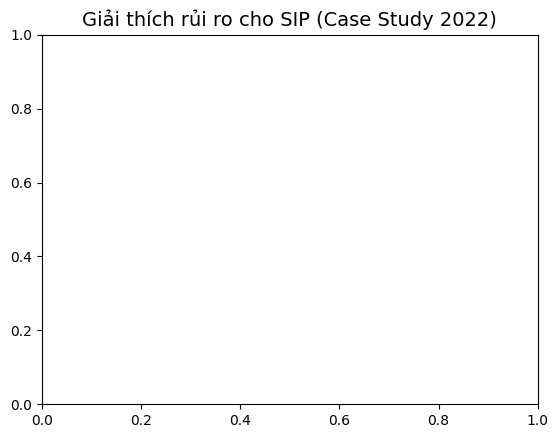

In [4]:
# ==========================================
# 4. PHÂN TÍCH SHAP TRÊN TOÀN BỘ DỮ LIỆU 2022
# ==========================================
X_test_sen = test_df[features_fin_sen]
X_test_scaled = final_pipe.named_steps['scaler'].transform(X_test_sen)

# Tính SHAP cho TOÀN BỘ tập test 2022
shap_values_all = explainer.shap_values(X_test_scaled)

if isinstance(shap_values_all, list):
    shap_values_distress = shap_values_all[1]
else:
    shap_values_distress = shap_values_all[:, :, 1]

# ==========================================
# 5. TÌM KIẾM CASE STUDY (Nới lỏng điều kiện)
# ==========================================
sen_idx = features_fin_sen.index('SEN')

# Điều kiện 1: Tin xấu (SEN < 0) và làm tăng rủi ro (SHAP > 0)
mask = (test_df['SEN'].values < 0) & (shap_values_distress[:, sen_idx] > 0)
candidate_indices = np.where(mask)[0]

if len(candidate_indices) == 0:
    print("Vẫn không tìm thấy tin xấu làm tăng rủi ro. Đang tìm mẫu SEN có tác động mạnh nhất nói chung...")
    # Điều kiện fallback: Tìm mẫu mà biến SEN có giá trị tuyệt đối SHAP lớn nhất
    best_sample_idx = np.argmax(np.abs(shap_values_distress[:, sen_idx]))
else:
    # Chọn mẫu có SHAP của SEN cao nhất trong các mẫu thỏa điều kiện
    best_sample_idx = candidate_indices[np.argmax(shap_values_distress[candidate_indices, sen_idx])]

selected_code = test_df.iloc[best_sample_idx]['Code']
selected_sen_val = test_df.iloc[best_sample_idx]['SEN']

print(f"\n--- ĐÃ TÌM THẤY DOANH NGHIỆP MẪU: {selected_code} ---")
print(f"Giá trị SEN thực tế: {selected_sen_val:.4f}")
print(f"SHAP value của SEN: {shap_values_distress[best_sample_idx, sen_idx]:.4f}")

# Vẽ Waterfall plot
plt.figure(figsize=(12, 8))
shap.plots._waterfall.waterfall_legacy(
    expected_value,
    shap_values_distress[best_sample_idx],
    feature_names=features_fin_sen,
    max_display=15
)
plt.title(f"Giải thích rủi ro cho {selected_code} (Case Study 2022)", fontsize=14)
plt.show()


--- ĐANG PHÂN TÍCH DOANH NGHIỆP: NVL ---
Giá trị SEN thực tế: 0.6579
SHAP value của SEN: -0.0410


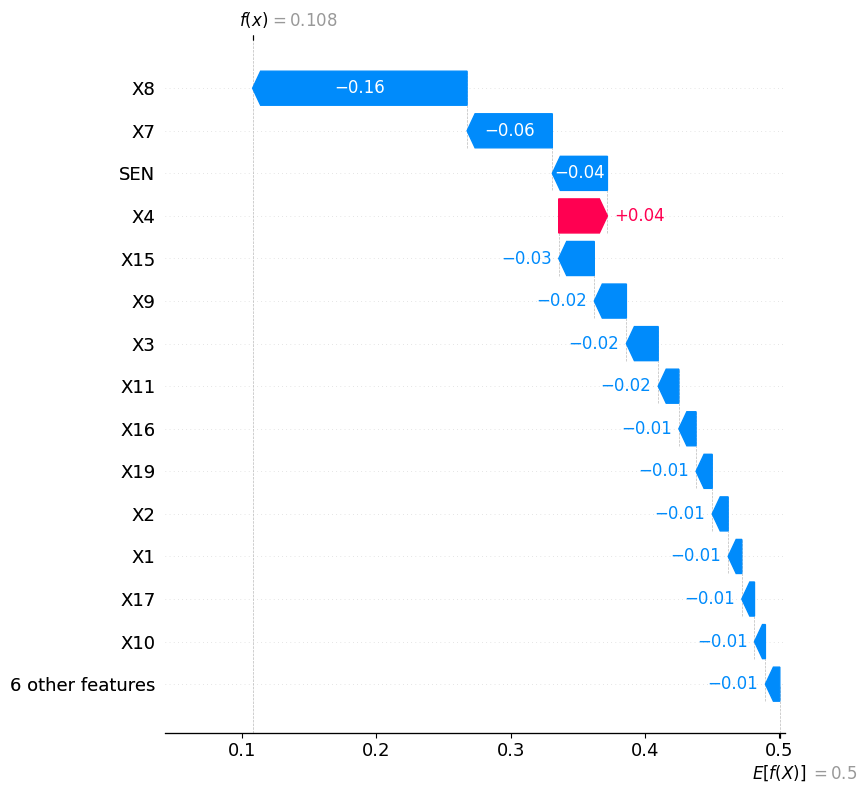

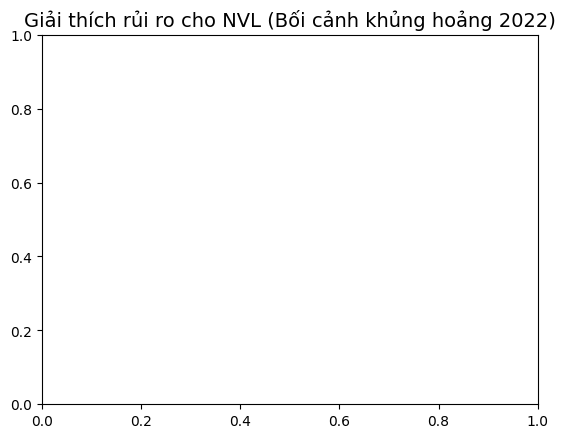


--- ĐANG PHÂN TÍCH DOANH NGHIỆP: PDR ---
Giá trị SEN thực tế: 0.7474
SHAP value của SEN: -0.0293


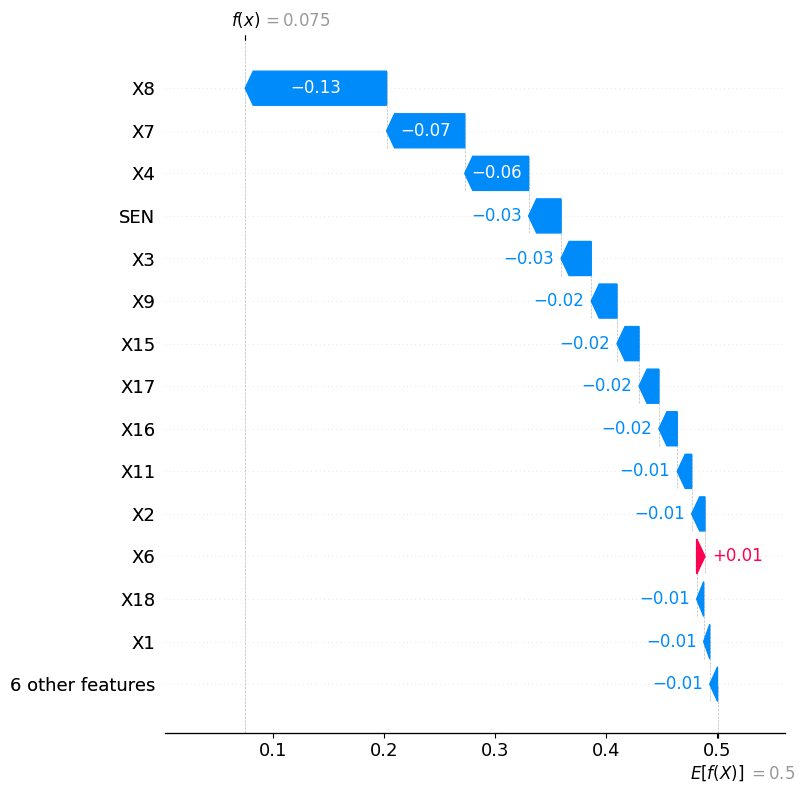

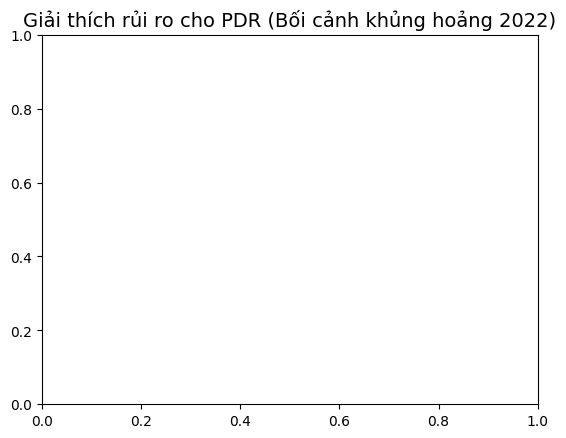

In [5]:
# Danh sách các mã "tâm điểm" năm 2022
target_codes = ['NVL', 'PDR']

for code in target_codes:
    # Tìm index của mã trong test_df
    idx_list = test_df.index[test_df['Code'] == code].tolist()

    if not idx_list:
        print(f"--- Không tìm thấy mã {code} trong dữ liệu năm 2022 ---")
        continue

    # Lấy vị trí tương ứng trong ma trận X_test_scaled (giả sử test_df không bị xáo trộn thứ tự)
    # Nếu có xáo trộn, ta cần map index cẩn thận hơn.
    # Thông thường idx_test = index_in_test_df - start_index_of_test_df
    start_idx_test = test_df.index[0]
    sample_idx = idx_list[0] - start_idx_test

    print(f"\n--- ĐANG PHÂN TÍCH DOANH NGHIỆP: {code} ---")
    print(f"Giá trị SEN thực tế: {test_df.loc[idx_list[0], 'SEN']:.4f}")
    print(f"SHAP value của SEN: {shap_values_distress[sample_idx, sen_idx]:.4f}")

    # Vẽ Waterfall plot
    plt.figure(figsize=(12, 8))
    shap.plots._waterfall.waterfall_legacy(
        expected_value,
        shap_values_distress[sample_idx],
        feature_names=features_fin_sen,
        max_display=15
    )
    plt.title(f"Giải thích rủi ro cho {code} (Bối cảnh khủng hoảng 2022)", fontsize=14)
    plt.show()

Danh sách các mã bị Distress thực tế năm 2022:
['HNG' 'SD2' 'SD4' 'SD3' 'DFF' 'SDA' 'SDD' 'BBT' 'SDP' 'SDT' 'BCC' 'BCE'
 'HOM' 'SDY' 'HOT' 'BCP' 'BCO' 'BCV' 'DHB' 'HPI' 'DID' 'DIC' 'JVC' 'HRT'
 'SHG' 'HSM' 'SIG' 'SII' 'HTE' 'DLD' 'DLG' 'BHG' 'HTM' 'SIV' 'HU4' 'DLR'
 'SJF' 'SJG' 'OCH' 'DND' 'HVN' 'DNM' 'HVX' 'UPH' 'FSO' 'HWS' 'DP2' 'SMC'
 'DPC' 'X77' 'FTI' 'SMT' 'BLF' 'FTM' 'MAS' 'E29' 'BMF' 'MCG' 'BNA' 'SP2'
 'SPB' 'SPD' 'SPC' 'MDF' 'DSD' 'DSG' 'DSP' 'MEC' 'DTC' 'OIL' 'DTL' 'SRA'
 'SRF' 'QNC' 'BQB' 'SRT' 'DUS' 'C47' 'DWC' 'STT' 'BSG' 'MIE' 'DXL' 'BTS'
 'SVD' 'BTV' 'SVG' 'C69' 'ICC' 'ICF' 'ICT' 'KHD' 'IDJ' 'C92' 'GAB' 'MML'
 'GCF' 'VAF' 'VBH' 'VC9' 'VCM' 'VCR' 'VCX' 'VDL' 'VE4' 'GGG' 'VE8' 'ECI'
 'MST' 'L18' 'VEA' 'VEC' 'MTA' 'MTG' 'TAR' 'ILS' 'CAB' 'CAD' 'L35' 'VGI'
 'TCK' 'TCR' 'MVN' 'VGV' 'TDC' 'VHD' 'VHH' 'VHL' 'CCP' 'VIE' 'CCT' 'TEL'
 'KTL' 'RAT' 'VIW' 'L61' 'L63' 'L62' 'CE1' 'RBC' 'GMC' 'CEG' 'EIN' 'VKC'
 'AAT' 'AAV' 'KVC' 'TH1' 'XPH' 'CFV' 'ISG' 'RDP' 'THU' 'ACS' 'VMG' 'CGV'
 'GP

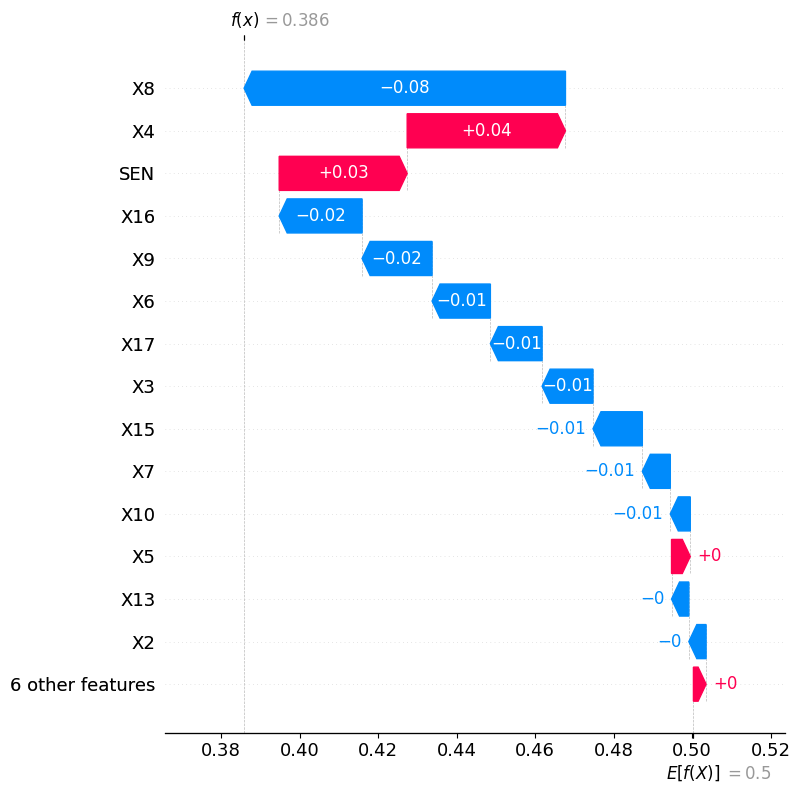

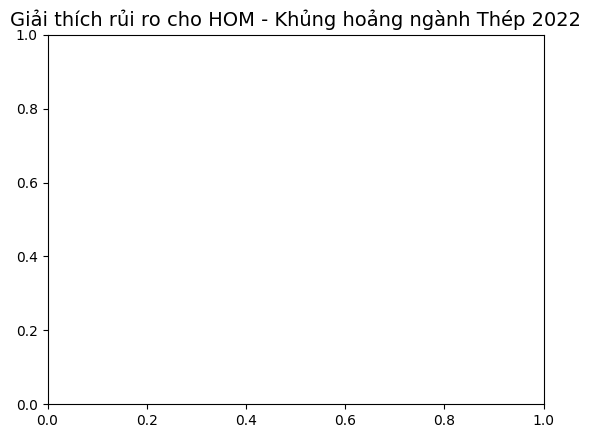

In [6]:
# Tìm những doanh nghiệp thực sự bị Distress (Label=1) trong năm 2022
distressed_real = test_df[test_df[target] == 1]

if not distressed_real.empty:
    print("Danh sách các mã bị Distress thực tế năm 2022:")
    print(distressed_real['Code'].unique())

    # Chọn mã đầu tiên để phân tích (ví dụ POM hoặc TIS)
    case_code = distressed_real['Code'].iloc[12]
    idx_in_test = test_df.index[test_df['Code'] == case_code][0]
    sample_idx = idx_in_test - test_df.index[0]

    print(f"\n--- PHÂN TÍCH CASE STUDY: {case_code} ---")

    # Vẽ Waterfall plot
    plt.figure(figsize=(12, 8))
    shap.plots._waterfall.waterfall_legacy(
        expected_value,
        shap_values_distress[sample_idx],
        feature_names=features_fin_sen,
        max_display=15
    )
    plt.title(f"Giải thích rủi ro cho {case_code} - Khủng hoảng ngành Thép 2022", fontsize=14)
    plt.show()
else:
    print("Không có mã Distress (1) trong tập test 2022.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


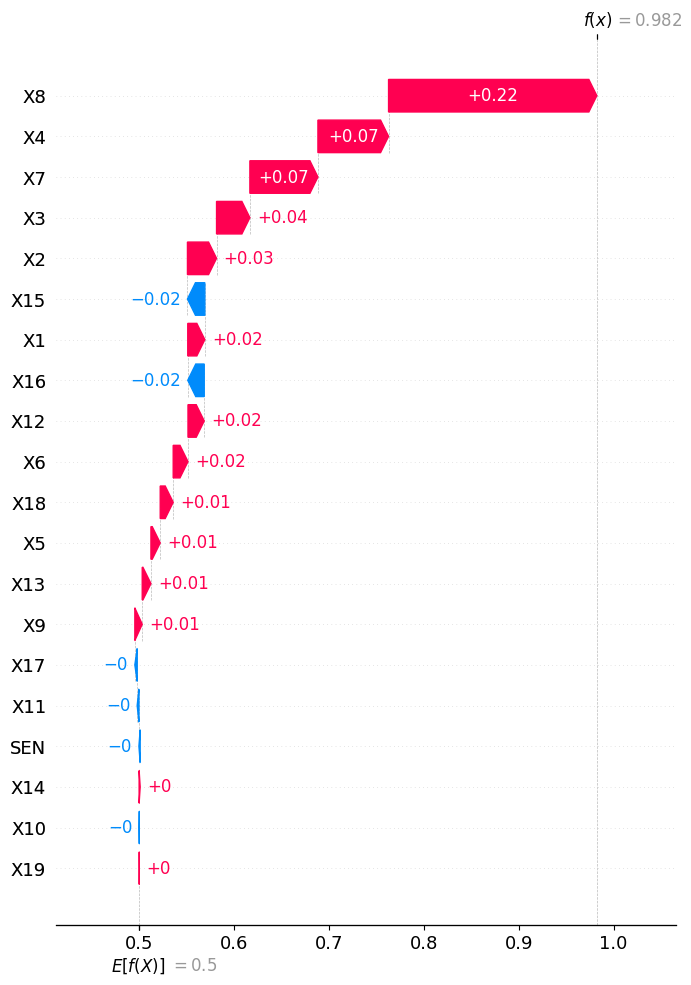

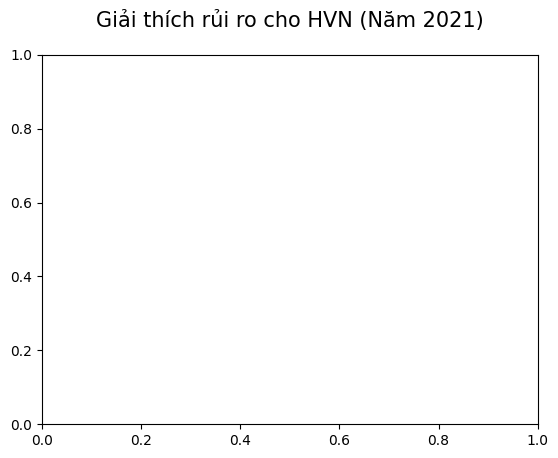

✅ Nhãn thực tế năm 2022: KIỆT QUỆ (1)


In [7]:
import pandas as pd
import numpy as np
import wandb
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# ==========================================
# 1. THAY ĐỔI THÔNG TIN Ở ĐÂY
# ==========================================
TARGET_CODE = 'HVN'  # Thay mã chứng khoán bạn muốn (VĐ: HQC, PVD, HVN, NVL...)
TARGET_YEAR = 2021   # Thay năm bạn muốn phân tích
FILE_PATH = "/content/drive/MyDrive/KLTN/FDP_VN_2010_2022_Train_Set.csv"

# ==========================================
# 2. CÀI ĐẶT VÀ LOAD DỮ LIỆU
# ==========================================
WANDB_API_KEY = "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"
wandb.login(key=WANDB_API_KEY)
api = wandb.Api()

df_raw = pd.read_csv(FILE_PATH)

# Huấn luyện trên dữ liệu TRƯỚC năm mục tiêu để dự báo cho năm mục tiêu
train_df = df_raw[df_raw['Year'] < TARGET_YEAR].copy()
# Lấy mẫu cụ thể để phân tích
case_df = df_raw[(df_raw['Code'] == TARGET_CODE) & (df_raw['Year'] == TARGET_YEAR)].copy()

if case_df.empty:
    print(f"❌ KHÔNG tìm thấy mã {TARGET_CODE} trong năm {TARGET_YEAR}!")
else:
    target = 'Next_year_binary_distress_label'
    fin_vars = [f'X{i}' for i in range(1, 20)]
    features = fin_vars + ['SEN']

    # ==========================================
    # 3. HUẤN LUYỆN MÔ HÌNH (Best Params từ WandB)
    # ==========================================
    run = api.run("22028316-uet-vnu/Distress_Prediction_KLTN/runs/nhxxygx7")
    best_params = {k.replace('rf__', ''): v for k, v in run.config.items()
                   if 'rf__' in k or k in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features', 'bootstrap']}

    final_pipe = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('rf', RandomForestClassifier(**best_params, random_state=42))
    ])
    final_pipe.fit(train_df[features], train_df[target])

    # ==========================================
    # 4. TÍNH SHAP CHO CASE STUDY
    # ==========================================
    X_case = final_pipe.named_steps['scaler'].transform(case_df[features])
    rf_model = final_pipe.named_steps['rf']
    explainer = shap.TreeExplainer(rf_model)

    # Tính toán SHAP
    shap_values = explainer.shap_values(X_case)

    # Lấy giá trị cho class 1 (Distress)
    if isinstance(shap_values, list):
        sv = shap_values[1][0]
        ev = explainer.expected_value[1]
    else:
        sv = shap_values[0, :, 1]
        ev = explainer.expected_value[1]

    # ==========================================
    # 5. VẼ BIỂU ĐỒ WATERFALL
    # ==========================================
    plt.figure(figsize=(12, 10))
    # Dùng waterfall_legacy để hiển thị giống định dạng cũ bạn đang dùng
    shap.plots._waterfall.waterfall_legacy(
        ev,
        sv,
        feature_names=features,
        max_display=20
    )
    plt.title(f"Giải thích rủi ro cho {TARGET_CODE} (Năm {TARGET_YEAR})", fontsize=15, pad=20)
    plt.show()

    # In ra nhãn thực tế để đối chiếu
    real_label = "KIỆT QUỆ (1)" if case_df[target].values[0] == 1 else "KHỎE MẠNH (0)"
    print(f"✅ Nhãn thực tế năm {TARGET_YEAR+1}: {real_label}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


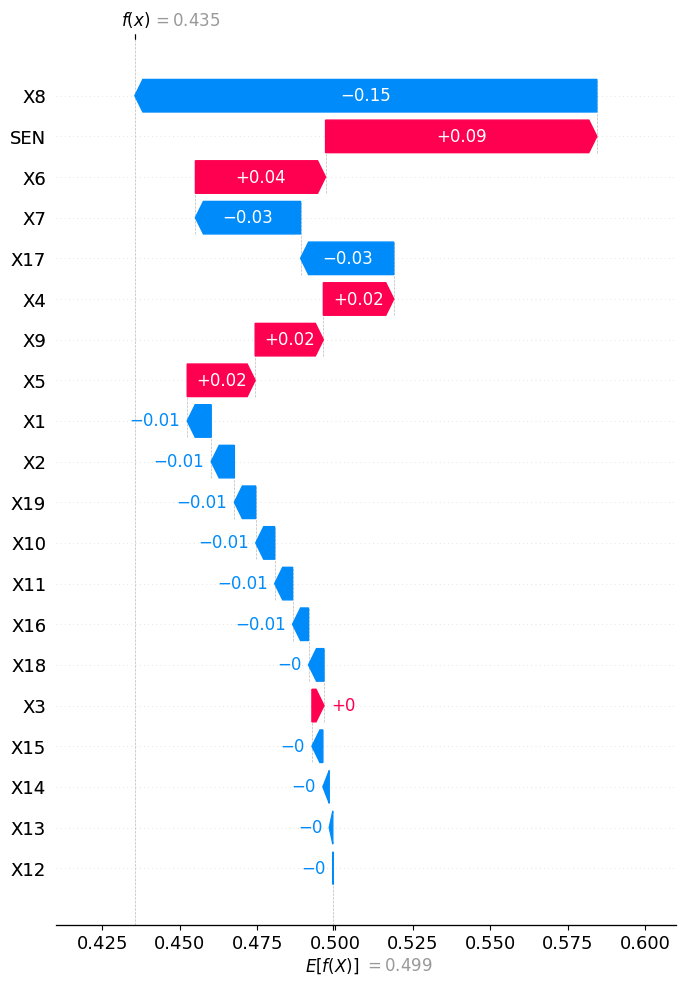

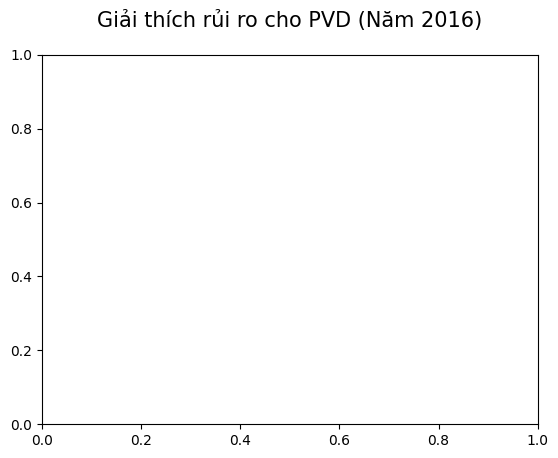

✅ Nhãn thực tế năm 2017: KHỎE MẠNH (0)


In [8]:
import pandas as pd
import numpy as np
import wandb
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# ==========================================
# 1. THAY ĐỔI THÔNG TIN Ở ĐÂY
# ==========================================
TARGET_CODE = 'PVD'  # Thay mã chứng khoán bạn muốn (VĐ: HQC, PVD, HVN, NVL...)
TARGET_YEAR = 2016   # Thay năm bạn muốn phân tích
FILE_PATH = "/content/drive/MyDrive/KLTN/FDP_VN_2010_2022_Train_Set.csv"

# ==========================================
# 2. CÀI ĐẶT VÀ LOAD DỮ LIỆU
# ==========================================
WANDB_API_KEY = "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"
wandb.login(key=WANDB_API_KEY)
api = wandb.Api()

df_raw = pd.read_csv(FILE_PATH)

# Huấn luyện trên dữ liệu TRƯỚC năm mục tiêu để dự báo cho năm mục tiêu
train_df = df_raw[df_raw['Year'] < TARGET_YEAR].copy()
# Lấy mẫu cụ thể để phân tích
case_df = df_raw[(df_raw['Code'] == TARGET_CODE) & (df_raw['Year'] == TARGET_YEAR)].copy()

if case_df.empty:
    print(f"❌ KHÔNG tìm thấy mã {TARGET_CODE} trong năm {TARGET_YEAR}!")
else:
    target = 'Next_year_binary_distress_label'
    fin_vars = [f'X{i}' for i in range(1, 20)]
    features = fin_vars + ['SEN']

    # ==========================================
    # 3. HUẤN LUYỆN MÔ HÌNH (Best Params từ WandB)
    # ==========================================
    run = api.run("22028316-uet-vnu/Distress_Prediction_KLTN/runs/nhxxygx7")
    best_params = {k.replace('rf__', ''): v for k, v in run.config.items()
                   if 'rf__' in k or k in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features', 'bootstrap']}

    final_pipe = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('rf', RandomForestClassifier(**best_params, random_state=42))
    ])
    final_pipe.fit(train_df[features], train_df[target])

    # ==========================================
    # 4. TÍNH SHAP CHO CASE STUDY
    # ==========================================
    X_case = final_pipe.named_steps['scaler'].transform(case_df[features])
    rf_model = final_pipe.named_steps['rf']
    explainer = shap.TreeExplainer(rf_model)

    # Tính toán SHAP
    shap_values = explainer.shap_values(X_case)

    # Lấy giá trị cho class 1 (Distress)
    if isinstance(shap_values, list):
        sv = shap_values[1][0]
        ev = explainer.expected_value[1]
    else:
        sv = shap_values[0, :, 1]
        ev = explainer.expected_value[1]

    # ==========================================
    # 5. VẼ BIỂU ĐỒ WATERFALL
    # ==========================================
    plt.figure(figsize=(12, 10))
    # Dùng waterfall_legacy để hiển thị giống định dạng cũ bạn đang dùng
    shap.plots._waterfall.waterfall_legacy(
        ev,
        sv,
        feature_names=features,
        max_display=20
    )
    plt.title(f"Giải thích rủi ro cho {TARGET_CODE} (Năm {TARGET_YEAR})", fontsize=15, pad=20)
    plt.show()

    # In ra nhãn thực tế để đối chiếu
    real_label = "KIỆT QUỆ (1)" if case_df[target].values[0] == 1 else "KHỎE MẠNH (0)"
    print(f"✅ Nhãn thực tế năm {TARGET_YEAR+1}: {real_label}")